# 00 · EDA — Jena Climate & UCI HAR

두 시계열 데이터셋을 탐색하고 **무작위 샘플을 즉시 확인**할 수 있는 노트북입니다.

- **Jena Climate** — 독일 막스플랑크 기상관측소, 10분 간격 14변수
- **UCI HAR** — 스마트폰 가속도/자이로 6가지 활동 분류 (128 timestep × 9 channel)

> ⚠️ 무작위 샘플 셀은 `seed=None`이라 **재실행할 때마다 다른 샘플**이 나옵니다. 같은 결과를 보고 싶으면 셀에서 `seed=42`처럼 지정하세요.

## 0. 환경 점검

In [1]:
import sys, platform
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
print('Python      :', platform.python_version())
print('Torch       :', torch.__version__)
print('CUDA avail  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device      :', torch.cuda.get_device_name(0))
    print('CUDA build  :', torch.version.cuda)

Python      : 3.12.3
Torch       : 2.5.1+cu124
CUDA avail  : True
Device      : NVIDIA GeForce RTX 4080
CUDA build  : 12.4


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader, visualize

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

## 1. Jena Climate

최초 1회만 다운로드 (~13MB). 이후 `data/raw/` 캐시 사용.

In [3]:
df = data_loader.load_jena_climate()
print('shape   :', df.shape)
print('range   :', df.index.min(), '→', df.index.max())
print('missing :', int(df.isna().sum().sum()))
df.head()

jena_climate_2009_2016.csv.zip: 100%|██████████████████████████████████████████████████████████| 13.6M/13.6M [00:00<00:00, -24.2MB/s]


shape   : (420551, 14)
range   : 2009-01-01 00:10:00 → 2017-01-01 00:00:00
missing : 0


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [4]:
df.dtypes

p (mbar)           float64
T (degC)           float64
Tpot (K)           float64
Tdew (degC)        float64
rh (%)             float64
VPmax (mbar)       float64
VPact (mbar)       float64
VPdef (mbar)       float64
sh (g/kg)          float64
H2OC (mmol/mol)    float64
rho (g/m**3)       float64
wv (m/s)           float64
max. wv (m/s)      float64
wd (deg)           float64
dtype: object

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
p (mbar),420551.0,989.212776,8.358481,913.60,984.20,989.58,994.72,1015.35
T (degC),420551.0,9.450147,8.423365,-23.01,3.36,9.42,15.47,37.28
Tpot (K),420551.0,283.492743,8.504471,250.60,277.43,283.47,289.53,311.34
Tdew (degC),420551.0,4.955854,6.730674,-25.01,0.24,5.22,10.07,23.11
rh (%),420551.0,76.008259,16.476175,12.95,65.21,79.30,89.40,100.00
VPmax (mbar),420551.0,13.576251,7.739020,0.95,7.78,11.82,17.60,63.77
VPact (mbar),420551.0,9.533756,4.184164,0.79,6.21,8.86,12.35,28.32
VPdef (mbar),420551.0,4.042412,4.896851,0.00,0.87,2.19,5.30,46.01
sh (g/kg),420551.0,6.022408,2.656139,0.50,3.92,5.59,7.80,18.13
H2OC (mmol/mol),420551.0,9.640223,4.235395,0.80,6.29,8.96,12.49,28.82


### 1.1 전체 기온 시계열 (다운샘플 시각화)

10분 간격이 너무 촘촘해서 6시간 평균으로 다운샘플링한 뒤 plot.

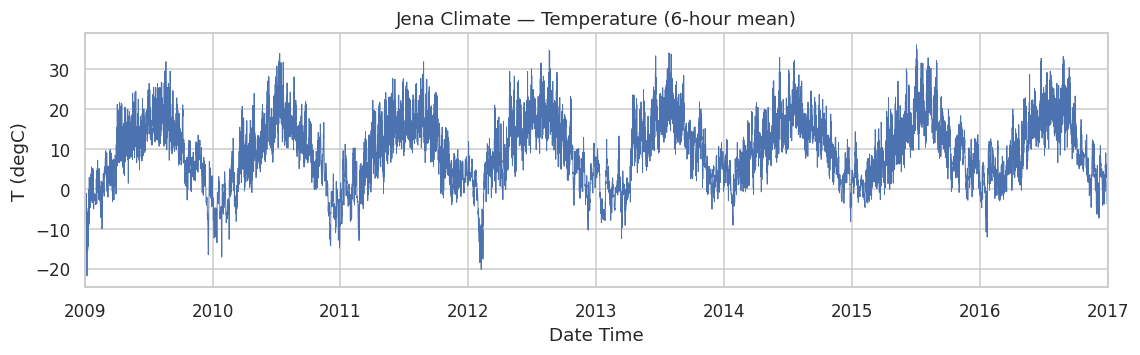

In [6]:
ax = df['T (degC)'].resample('6h').mean().plot(figsize=(12, 3), lw=0.6)
ax.set_title('Jena Climate — Temperature (6-hour mean)')
ax.set_ylabel('T (degC)')
plt.show()

### 1.2 ★ 무작위 샘플 뷰어

아래 셀들을 **여러 번 재실행**해 보세요 — 매번 다른 시점 / 다른 행이 나옵니다.

In [7]:
# 무작위로 10개 행 보기 (실제 데이터가 어떤 모양인지)
df.sample(10).sort_index()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-14 06:10:00,986.76,-9.08,265.09,-10.31,90.70,3.07,2.78,0.29,1.76,2.82,1300.30,0.76,1.50,176.30
2010-01-06 21:50:00,978.31,-9.98,264.84,-11.97,85.20,2.86,2.43,0.42,1.55,2.49,1293.73,1.23,2.12,240.40
2010-04-28 09:50:00,1000.41,14.12,287.25,6.10,58.41,16.13,9.42,6.71,5.88,9.42,1208.80,1.62,3.36,101.80
2010-08-31 13:30:00,993.06,15.91,289.65,6.56,53.73,18.11,9.73,8.38,6.12,9.80,1192.31,2.18,4.64,8.17
2011-03-12 12:10:00,985.35,10.90,285.26,0.78,49.50,13.06,6.46,6.59,4.09,6.56,1205.40,4.00,5.48,163.00
2011-12-17 01:00:00,959.97,2.87,279.28,-0.59,77.90,7.51,5.85,1.66,3.80,6.10,1208.72,4.13,9.63,269.70
2012-09-20 18:40:00,995.99,12.19,285.68,3.24,54.24,14.22,7.71,6.51,4.83,7.74,1212.36,2.45,2.88,236.00
2015-05-30 08:40:00,985.30,11.76,286.13,6.21,68.69,13.82,9.49,4.33,6.02,9.64,1200.30,4.61,6.45,247.40
2015-06-10 17:40:00,996.93,19.89,293.31,7.54,44.74,23.26,10.41,12.85,6.52,10.44,1180.41,4.19,6.97,69.48


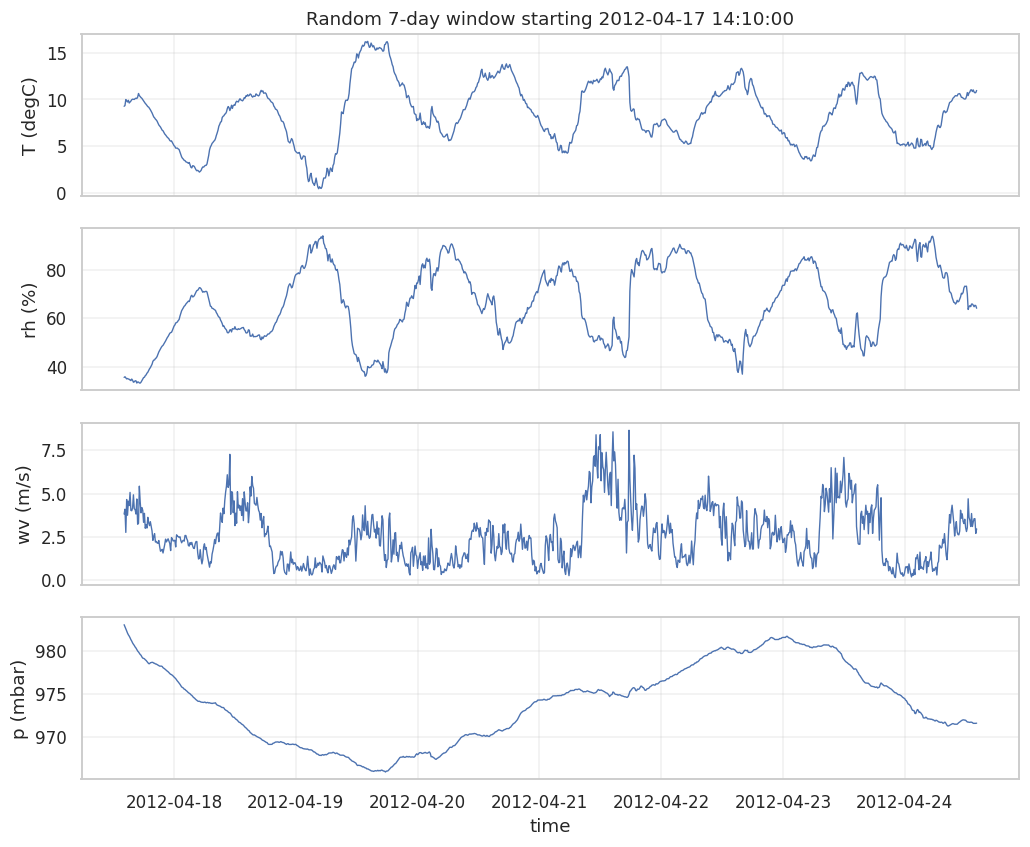

In [8]:
# 무작위 7일 구간의 4개 변수 시계열
_ = visualize.plot_random_climate_window(
    df, days=7,
    columns=('T (degC)', 'rh (%)', 'wv (m/s)', 'p (mbar)'),
    seed=None,
)
plt.show()

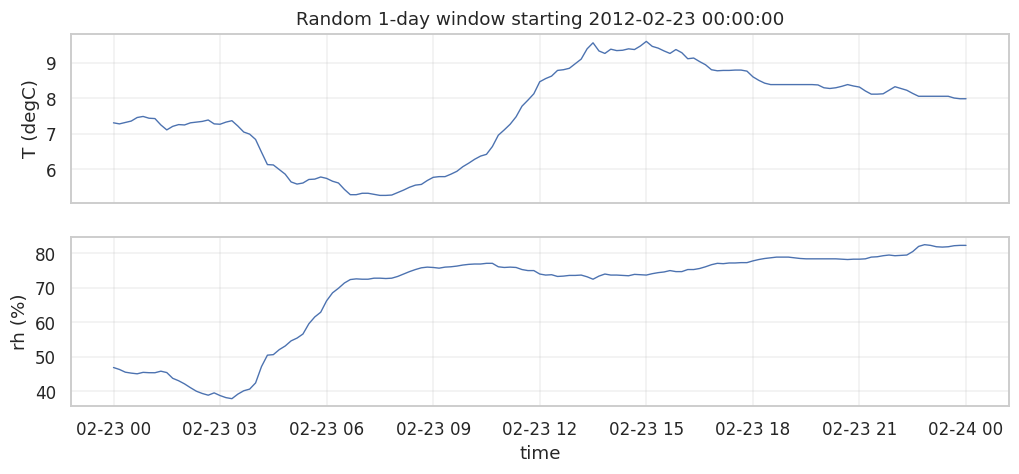

In [9]:
# 무작위 1일 구간의 기온/습도
_ = visualize.plot_random_climate_window(
    df, days=1,
    columns=('T (degC)', 'rh (%)'),
    seed=None,
)
plt.show()

### 1.3 계절성 분해 (월 평균 기온)

/tmp/ipykernel_3557/356645599.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_T = df['T (degC)'].resample('1M').mean().dropna()


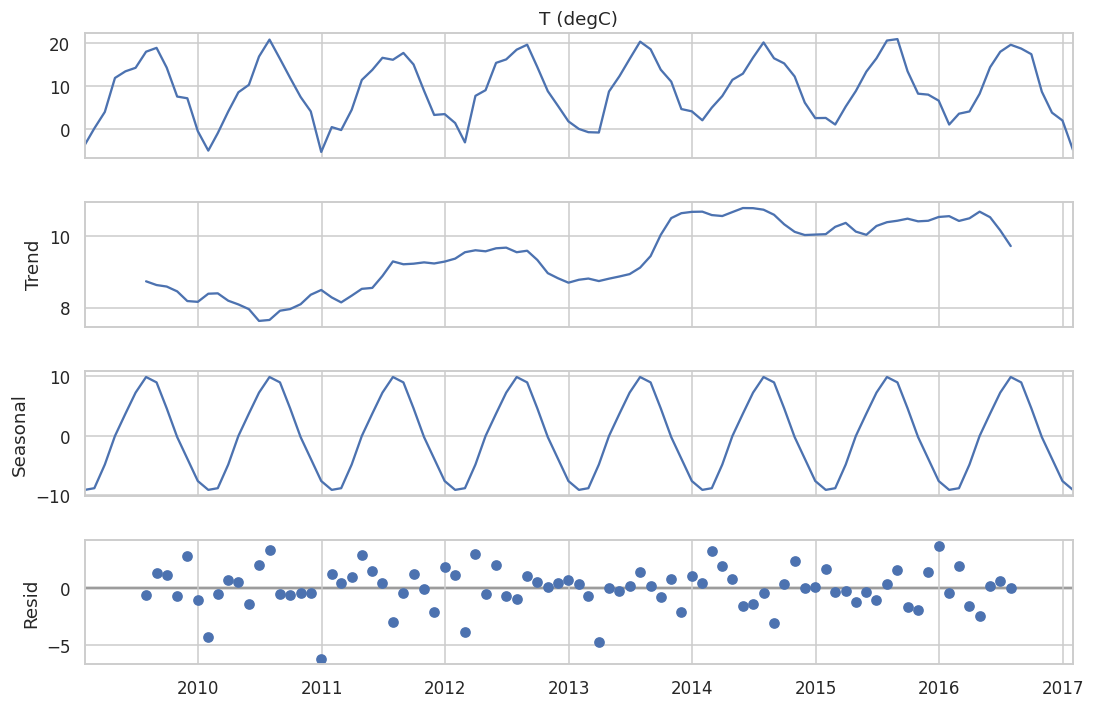

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_T = df['T (degC)'].resample('1M').mean().dropna()
result = seasonal_decompose(monthly_T, model='additive', period=12)
fig = result.plot()
fig.set_size_inches(11, 7)
plt.show()

### 1.4 ACF / PACF (시간 단위 다운샘플)

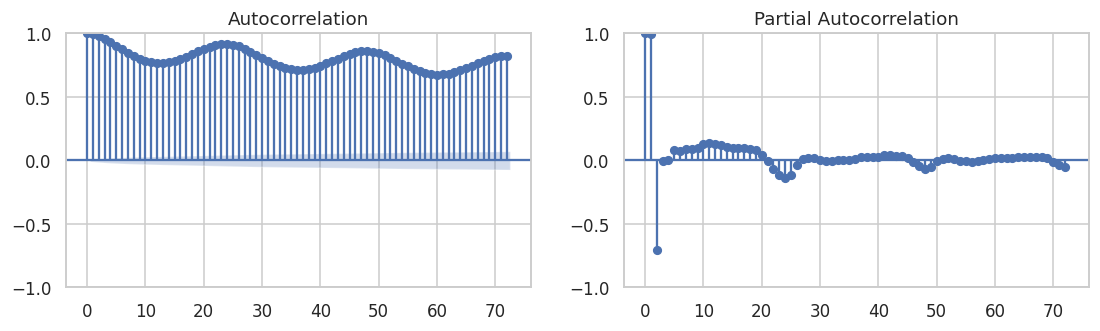

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

hourly = df['T (degC)'].resample('1h').mean().dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
plot_acf(hourly, lags=72, ax=axes[0])  # 3 days
plot_pacf(hourly, lags=72, ax=axes[1], method='ywm')
plt.show()

## 2. UCI HAR (Human Activity Recognition)

최초 1회만 다운로드 (~60MB). 9채널(가속도 x/y/z, 자이로 x/y/z, 합산 가속 x/y/z) × 128 timestep 윈도우.

In [12]:
har = data_loader.load_uci_har()
print('X_signals_train :', har['X_signals_train'].shape)
print('X_features_train:', har['X_features_train'].shape)
print('y_train         :', har['y_train'].shape, '— uniques:', sorted(set(har['y_train'].tolist())))
print('X_signals_test  :', har['X_signals_test'].shape)
print('y_test          :', har['y_test'].shape)
print('label map       :', har['label_names'])
print('channels        :', har['channel_names'])

UCI_HAR_Dataset.zip: 61.0MB [00:03, 17.4MB/s]


X_signals_train : (7352, 128, 9)
X_features_train: (7352, 561)
y_train         : (7352,) — uniques: [1, 2, 3, 4, 5, 6]
X_signals_test  : (2947, 128, 9)
y_test          : (2947,)
label map       : {1: 'WALKING', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'}
channels        : ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']


### 2.1 클래스 분포

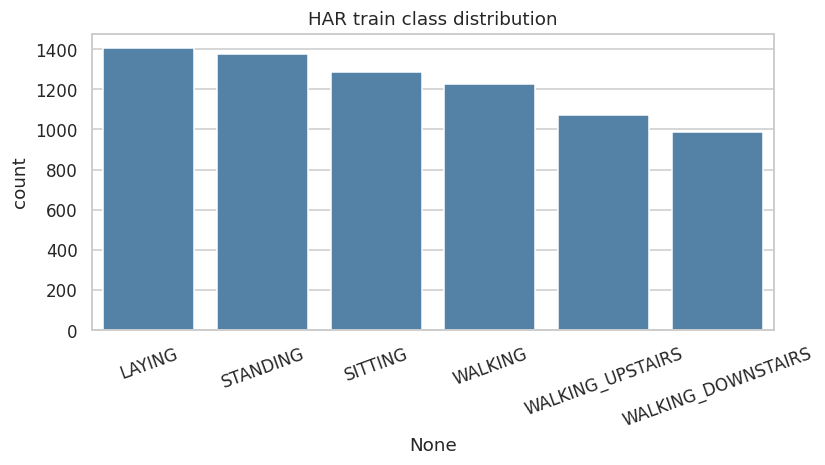

In [13]:
_ = visualize.plot_har_class_distribution(
    har['y_train'], har['label_names'], title='HAR train class distribution'
)
plt.show()

### 2.2 ★ 무작위 샘플 뷰어

아래 셀들을 여러 번 재실행해 보세요.

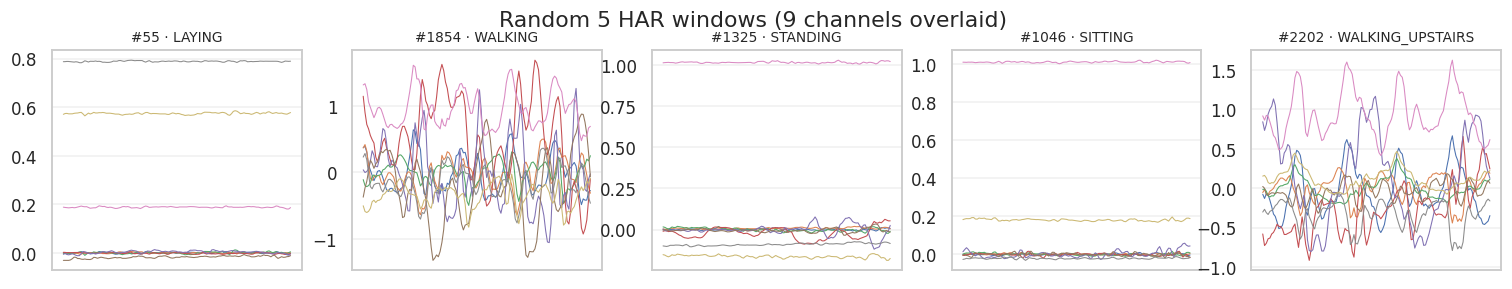

In [14]:
# 무작위 5개 윈도우 — 9채널 모두 한 subplot에 겹쳐서
_ = visualize.plot_random_har_samples(
    har['X_signals_train'], har['y_train'],
    label_names=har['label_names'], channel_names=har['channel_names'],
    n=5, seed=None,
)
plt.show()

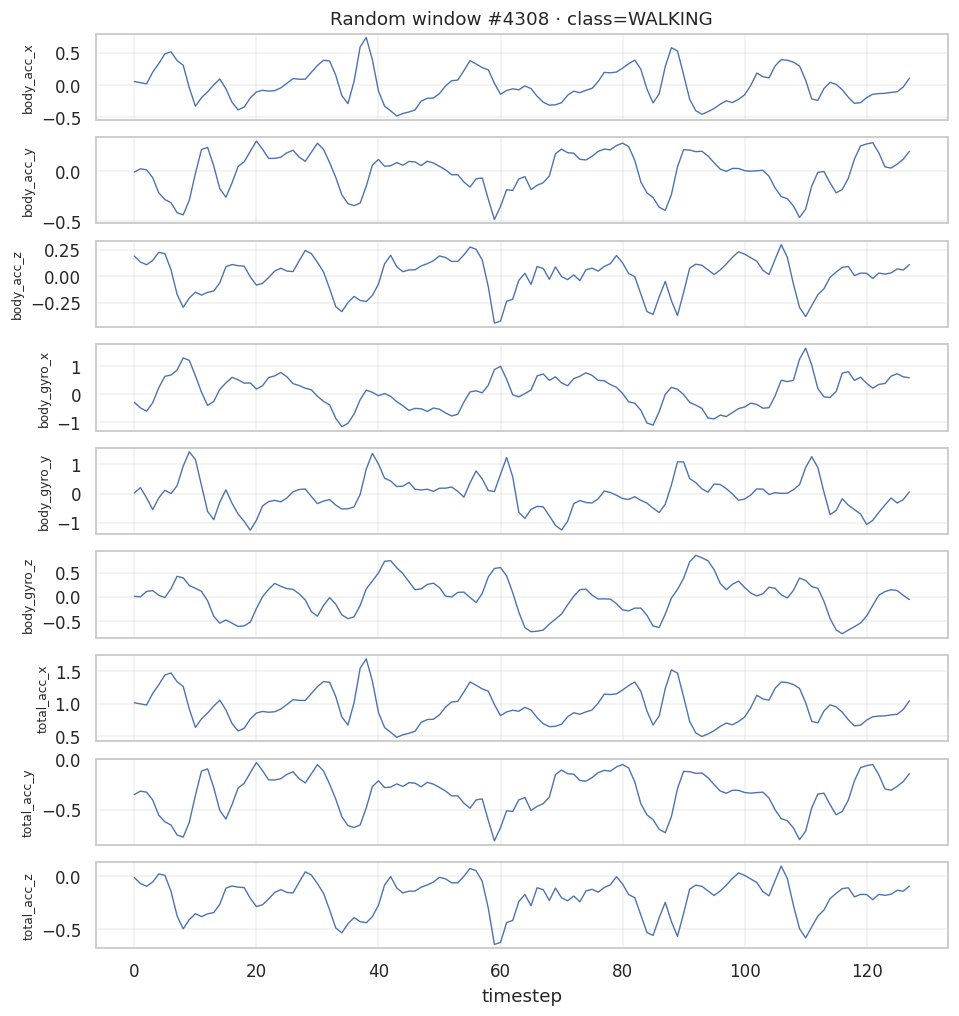

In [15]:
# 무작위 클래스 → 무작위 윈도우 → 9채널 stack plot
_ = visualize.plot_random_har_class_signals(
    har['X_signals_train'], har['y_train'],
    label_names=har['label_names'], channel_names=har['channel_names'],
    seed=None,
)
plt.show()

### 2.3 활동별 평균 |signal| heatmap

각 활동(class)이 어떤 채널에서 큰 값을 보이는지 한눈에 파악.

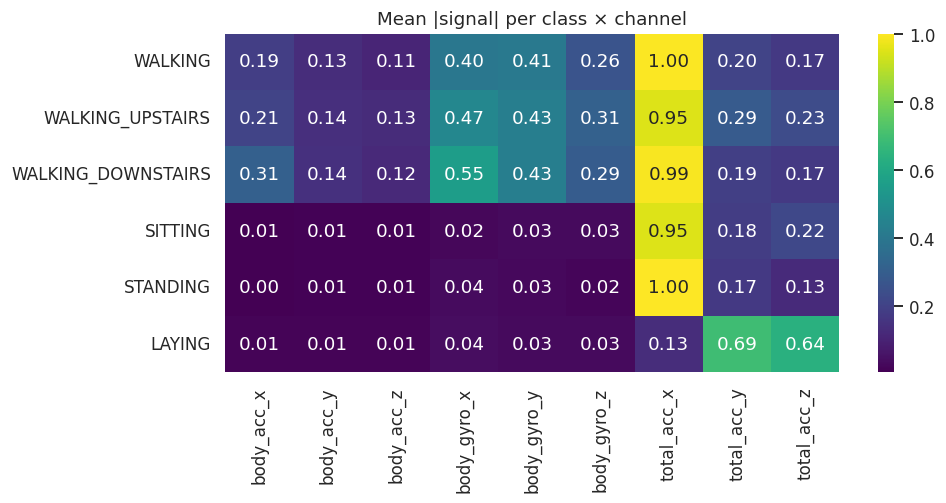

In [16]:
_ = visualize.plot_har_mean_signal_heatmap(
    har['X_signals_train'], har['y_train'],
    label_names=har['label_names'], channel_names=har['channel_names'],
)
plt.show()

### 2.4 561개 handcrafted feature 일부 분포

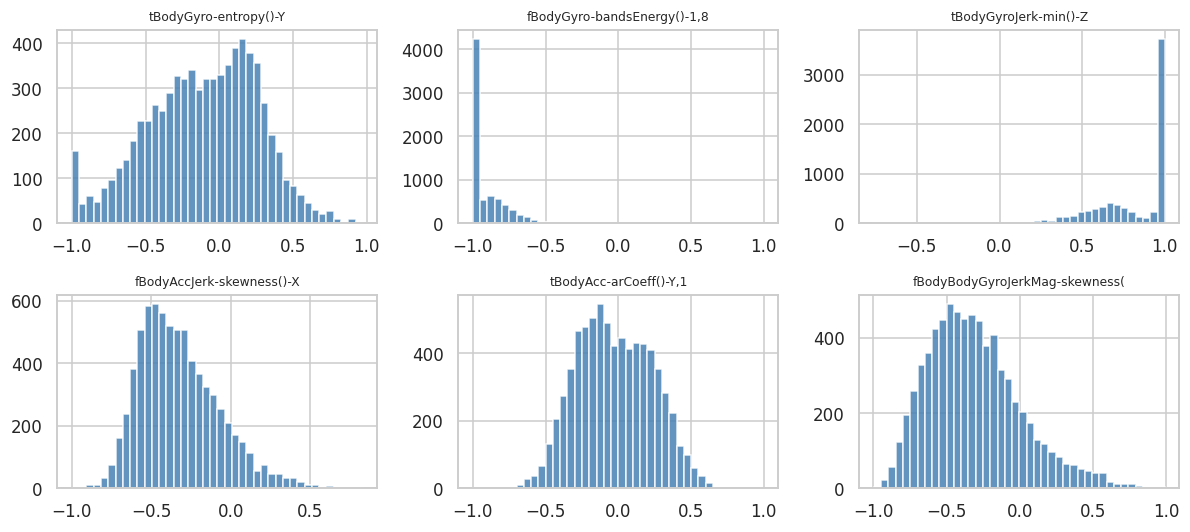

In [17]:
X_feat = har['X_features_train']
feature_names = har['feature_names']
rng = np.random.default_rng(None)
sel = rng.choice(X_feat.shape[1], size=6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(11, 5))
for ax, idx in zip(axes.flat, sel):
    ax.hist(X_feat[:, idx], bins=40, color='steelblue', alpha=0.85)
    ax.set_title(feature_names[idx][:30], fontsize=8)
plt.tight_layout()
plt.show()

## 3. 결론 메모

여기에 EDA에서 발견한 점을 자유롭게 적어주세요.

- 예) Jena 기온은 강한 연 단위 계절성, 일 단위 진동도 뚜렷 → SARIMA에 (period=24, period=8760) 시도 가치
- 예) HAR에서 LAYING 활동은 가속도가 거의 0에 가까움 → CNN이 쉽게 분리할 듯
- ...